In [1]:
import math

from scipy.io import arff
from operator import index

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors, KernelDensity
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import scipy.stats
from scipy.stats import expon, skew, norm,gamma, anderson,goodness_of_fit, monte_carlo_test, probplot, skewnorm
from scipy import integrate
from sklearn.metrics import auc
import seaborn as sns
import math

from statsmodels.sandbox.distributions.gof_new import kstest

plt.rcParams['figure.figsize'] = [15, 7]
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

In [2]:
import numpy as np

from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import roc_auc_score

from scipy.stats import gamma

import pandas as pd



# Simulation parameters

runs = 500

n_train = 200

n_test = 200

k = 5



# Gamma distribution parameters for inliers and outliers

a_in, scale_in = 2.0, 2.0

a_out, scale_out = 5.0, 2.0



# Arrays to store AUC results

auc_lr = np.zeros(runs)

auc_knn = np.zeros(runs)



for i in range(runs):

    # Generate training inliers for KNN

    train_in = np.random.gamma(a_in, scale_in, size=n_train)



    # Generate test samples

    test_in = np.random.gamma(a_in, scale_in, size=n_test)

    test_out = np.random.gamma(a_out, scale_out, size=n_test)



    # True labels: 0 for inliers, 1 for outliers

    y_true = np.concatenate([np.zeros(n_test), np.ones(n_test)])



    # LR scores: log(g/f)

    f_in = gamma.pdf(test_in, a=a_in, scale=scale_in)

    g_in = gamma.pdf(test_in, a=a_out, scale=scale_out)

    s_in = np.log(g_in / f_in)



    f_out = gamma.pdf(test_out, a=a_in, scale=scale_in)

    g_out = gamma.pdf(test_out, a=a_out, scale=scale_out)

    s_out = np.log(g_out / f_out)



    y_scores_lr = np.concatenate([s_in, s_out])

    auc_lr[i] = roc_auc_score(y_true, y_scores_lr)



    # KNN distance scores

    nbrs = NearestNeighbors(n_neighbors=k).fit(train_in.reshape(-1, 1))

    test_vals = np.concatenate([test_in, test_out]).reshape(-1, 1)

    distances, _ = nbrs.kneighbors(test_vals)

    d_k = distances[:, -1]  # distance to k-th neighbor



    # Use distance as the outlier score

    y_scores_knn = d_k

    auc_knn[i] = roc_auc_score(y_true, y_scores_knn)



# Summarize results

df_results = pd.DataFrame({

    'AUC_LR': auc_lr,

    'AUC_kNN': auc_knn

})


print(df_results)

       AUC_LR   AUC_kNN
0    0.893900  0.845175
1    0.850675  0.789050
2    0.888625  0.819850
3    0.892175  0.868225
4    0.891275  0.839475
..        ...       ...
495  0.887925  0.835325
496  0.909950  0.874475
497  0.896025  0.843600
498  0.858750  0.813100
499  0.905025  0.882700

[500 rows x 2 columns]


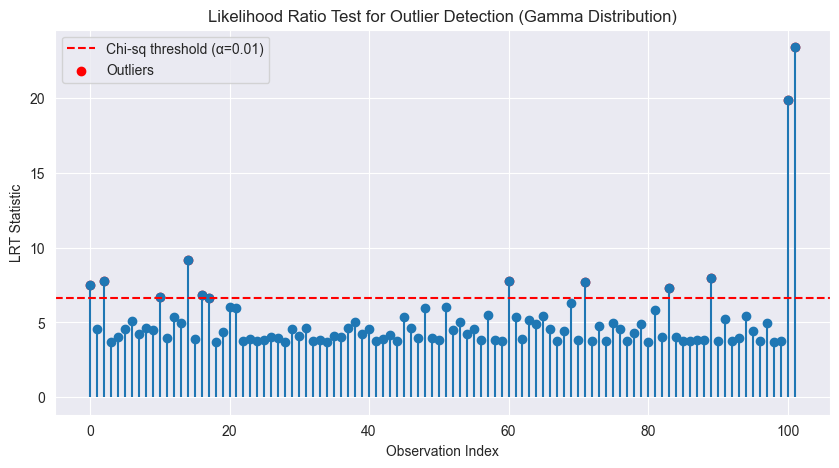

Outlier indices: [  0   2  10  14  16  17  60  71  83  89 100 101]
Outlier values: [10.27765915 10.85426455  8.87057547 13.29927073  9.06385095  8.74856747
 10.85427005 10.75082207 10.00277963 11.20961668 30.         35.        ]


In [3]:
import numpy as np
from scipy.stats import gamma, chi2
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Simulated data with some outliers
np.random.seed(0)
data = gamma.rvs(a=2, scale=2, size=100)
data_with_outliers = np.concatenate([data, [30, 35]])  # Inject outliers

# Log-likelihood function for Gamma distribution
def gamma_log_likelihood(params, data):
    a, scale = params
    if a <= 0 or scale <= 0:
        return -np.inf  # log-likelihood undefined for non-positive params
    return np.sum(gamma.logpdf(data, a=a, scale=scale))

# Fit full model
def fit_gamma(data):
    neg_log_likelihood = lambda params: -gamma_log_likelihood(params, data)
    result = minimize(neg_log_likelihood, x0=[1.0, 1.0], method='L-BFGS-B', bounds=[(1e-6, None), (1e-6, None)])
    return result.x, -result.fun  # return MLE and log-likelihood

# Likelihood ratio test for each point
def likelihood_ratio_test(data):
    full_params, full_loglike = fit_gamma(data)
    test_stats = []

    for i in range(len(data)):
        reduced_data = np.delete(data, i)
        reduced_params, reduced_loglike = fit_gamma(reduced_data)

        # LRT statistic: -2 * (logL0 - logL1)
        lambda_stat = -2 * (full_loglike - reduced_loglike)
        test_stats.append(lambda_stat)

    return np.array(test_stats), full_params

# Run LRT
lrt_stats, params = likelihood_ratio_test(data_with_outliers)

# Threshold using chi-squared distribution (1 df)
alpha = 0.01
threshold = chi2.ppf(1 - alpha, df=1)
outliers = np.where(lrt_stats > threshold)[0]

# Plotting
plt.figure(figsize=(10, 5))
plt.stem(lrt_stats, basefmt=" ")
plt.axhline(threshold, color='red', linestyle='--', label=f'Chi-sq threshold (α={alpha})')
plt.scatter(outliers, lrt_stats[outliers], color='red', label='Outliers')
plt.xlabel('Observation Index')
plt.ylabel('LRT Statistic')
plt.title('Likelihood Ratio Test for Outlier Detection (Gamma Distribution)')
plt.legend()
plt.show()

print("Outlier indices:", outliers)
print("Outlier values:", data_with_outliers[outliers])


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 1.]


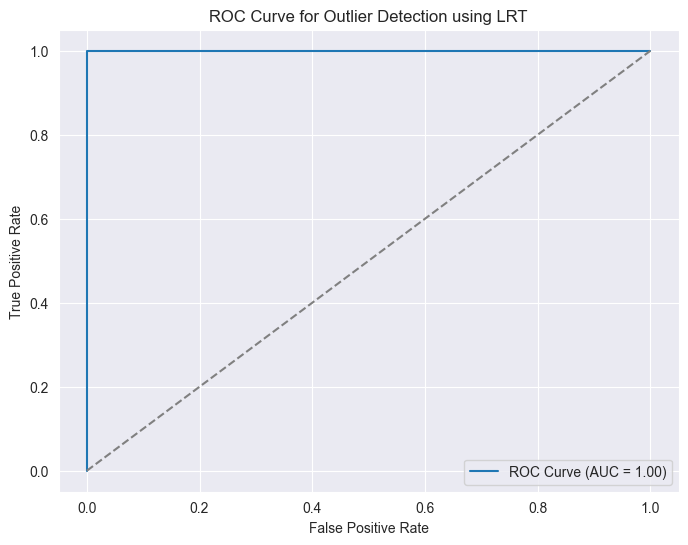

AUC: 1.0


In [13]:
import numpy as np
from scipy.stats import gamma, chi2
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Simulate gamma-distributed data and inject known outliers
np.random.seed(0)
n_normal = 100
data = gamma.rvs(a=2, scale=2, size=n_normal)
outliers = np.array([30, 35])  # known outliers
data_with_outliers = np.concatenate([data, outliers])

# Ground truth labels: 0 = inlier, 1 = outlier
labels = np.concatenate([np.zeros(n_normal), np.ones(len(outliers))])

# Log-likelihood function
def gamma_log_likelihood(params, data):
    a, scale = params
    if a <= 0 or scale <= 0:
        return -np.inf
    return np.sum(gamma.logpdf(data, a=a, scale=scale))

# Fit gamma using MLE
def fit_gamma(data):
    neg_log_likelihood = lambda params: -gamma_log_likelihood(params, data)
    result = minimize(neg_log_likelihood, x0=[1.0, 1.0], method='L-BFGS-B', bounds=[(1e-6, None), (1e-6, None)])
    return result.x, -result.fun

# LRT for each point
def likelihood_ratio_test(data):
    full_params, full_loglike = fit_gamma(data)
    test_stats = []
    #print(full_loglike)

    for i in range(len(data)):
        reduced_data = np.delete(data, i)
        _, reduced_loglike = fit_gamma(reduced_data)
        lambda_stat = -2 * (full_loglike - reduced_loglike)
        test_stats.append(lambda_stat)

    return np.array(test_stats)

# Run test
lrt_stats = likelihood_ratio_test(data_with_outliers)
print(labels)
# ROC AUC Calculation
roc_auc = roc_auc_score(labels, lrt_stats)
fpr, tpr, _ = roc_curve(labels, lrt_stats)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Outlier Detection using LRT')
plt.legend()
plt.grid(True)
plt.show()

# Output results
print("AUC:", roc_auc)


In [48]:
arff_file = arff.loadarff(f'./semantic/Annthyroid/Annthyroid_withoutdupl_norm_07.arff') # import the attribute-relation file format
df4 = pd.DataFrame(arff_file[0])
X = df4.drop(columns=['outlier','id']).values
#get outlier values
y = df4['outlier'].values
le = LabelEncoder()
#encoded the variables as 0=non-outlier, 1=outlier
y = le.fit_transform(y)

nn = NearestNeighbors(n_neighbors=6, p=1)
nn.fit(X, y)
dist, knn = nn.kneighbors(X,n_neighbors=6)
arr = []
for z in dist:
    arr += [np.max(z)]

params = gamma.fit(arr)
log_likelihood = np.sum(gamma.logpdf(arr,params[0],params[1],params[2]))
print(log_likelihood)
test_stats = []
#print(full_loglike)

for i in range(len(arr)):
    reduced_data = np.delete(arr, i)
    params = gamma.fit(reduced_data)
    reduced_likelihood = np.sum(gamma.logpdf(reduced_data,params[0],params[1],params[2]))
    lambda_stat = -2 * (log_likelihood - reduced_likelihood)
    test_stats.append(lambda_stat)

print(test_stats)
roc_auc = roc_auc_score(y, test_stats)
print(roc_auc)

6390.507199767449


KeyboardInterrupt: 